# Practical 3: Data Cleaning and Visualization

##  Data Cleaning and Visualization in Python

1.0.1 1. Import the necessary libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

1.0.2 2. Loading and Exploration

In [3]:
df = sns.load_dataset("titanic")
print(df.shape)
df.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.info() #column names, data types, missing values, memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [10]:
df.describe() # numerical

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.describe(include=['object', 'category']) # categorical

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [11]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [13]:
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 107


## 1.1 Data Cleaning

1.1.1 Handling Missing Values

In [15]:
df_clean = df.drop(columns=["deck"])

In [20]:
median_age = df_clean["age"].median()
df_clean["age"].fillna(median_age, inplace=True)

In [21]:
mode_embarked = df_clean["embarked"].mode()[0]
df_clean["embarked"].fillna(mode_embarked, inplace=True)

In [26]:
mode_embark_towb = df_clean["embark_town"].mode()[0]
df_clean["embark_town"].fillna(mode_embark_towb, inplace=True)

1.1.2 Data Types and Categories

In [30]:
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    category
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    category
dtypes: category(6), float64(2), int64(4), object(2)
memory usage: 61.7+ KB


1.1.3 Duplicates and Redundant Columns

In [34]:
df_clean.drop_duplicates(inplace=True)

In [35]:
df_clean.drop(columns=['alive', 'pclass', 'emba
rk_town'],inplace=True, errors='ignore')

In [36]:
df_clean.head()

,survived,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,male,35.0,0,0,8.0500,S,Third,man,True,True


1.1.4 Outlier Detection

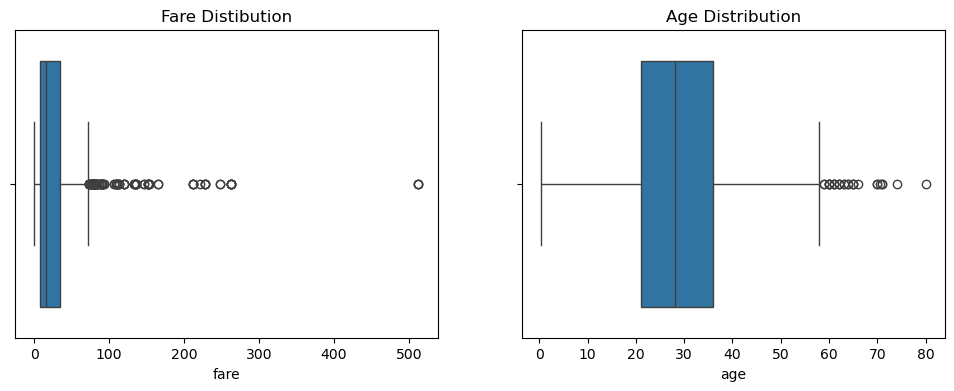

In [42]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(x=df_clean['fare'])
plt.title('Fare Distibution')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['age'])
plt.title('Age Distribution')

plt.show()

In [45]:
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q2 - Q1

upper_bound = Q3 + 1.5 * IQR

print(f"Fares above {upper_bound:.2f} are potential outliers.")
df_clean['fare_capped'] = df_clean['fare'].clip(upper=upper_bound)

Fares above 73.42 are potential outliers.


## 1.2 Visualizations

1.2.1 Univariate Plots

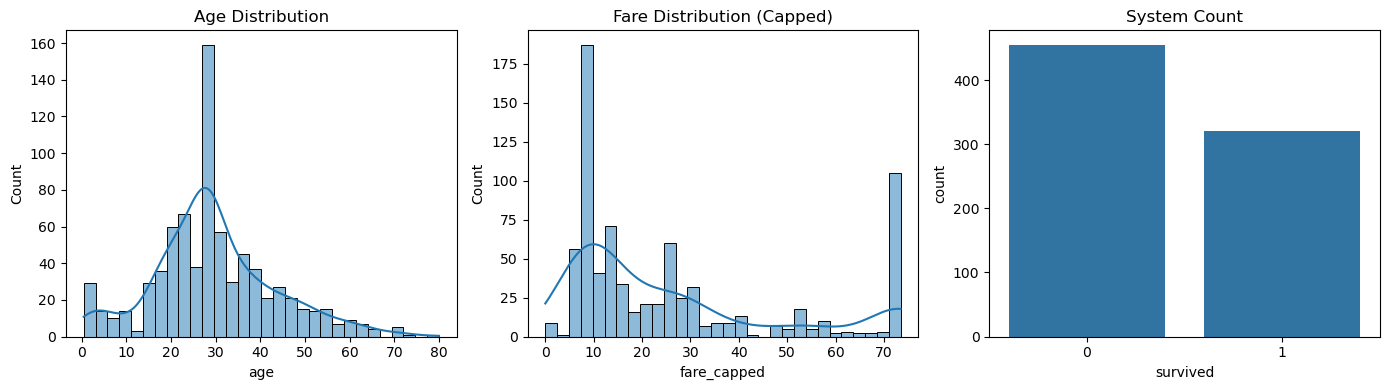

In [53]:
 plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['age'], kde=True,bins=30)
plt.title("Age Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df_clean['fare_capped'], kde=True, bins=30)
plt.title('Fare Distribution (Capped)')

plt.subplot(1, 3, 3)
sns.countplot(x = df_clean['survived'], data=df_clean)
plt.title('System Count')plt.title('Fare Distribution (Capped)')

plt.tight_layout()
plt.show()

1.2.2 Categorical Relationships

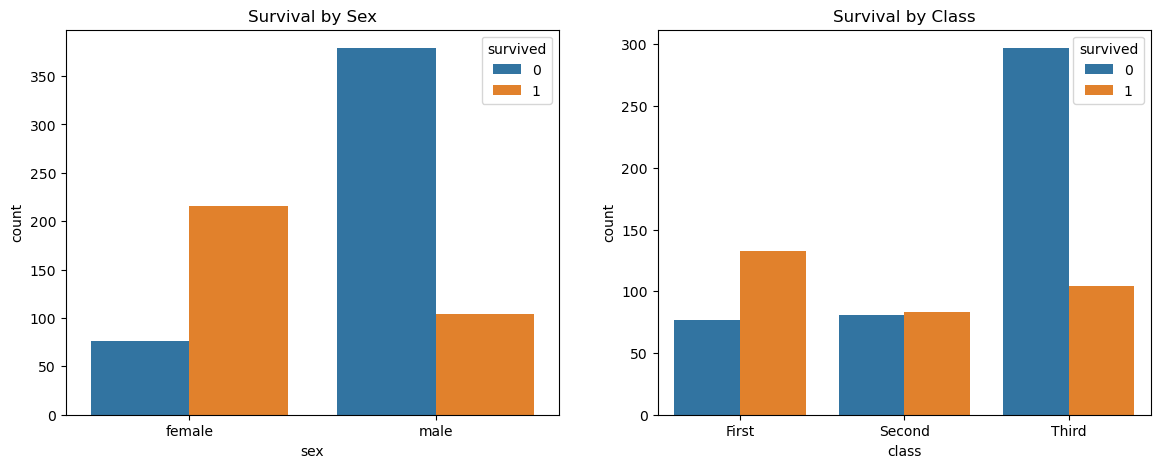

In [59]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='sex', hue='survived', data=df_clean)
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(x='class', hue='survived', data=df_clean)
plt.title('Survival by Class')

plt.show()

1.2.3 Numerical Relationships

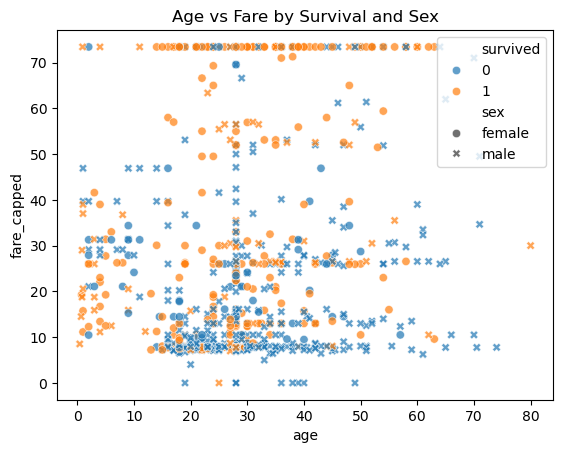

In [62]:
sns.scatterplot(x='age', y='fare_capped', hue='survived', style='sex', alpha=0.7, data=df_clean)
plt.title('Age vs Fare by Survival and Sex')
plt.show()


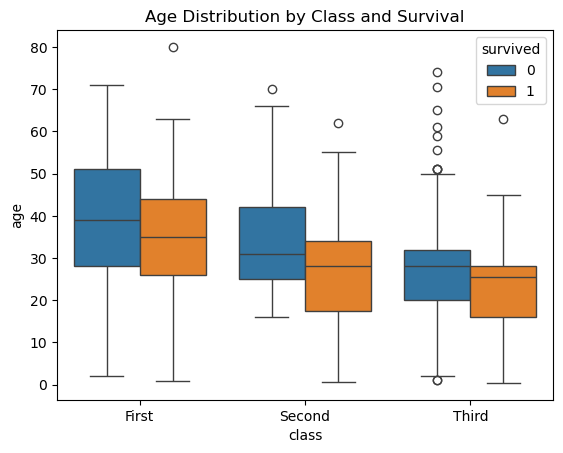

In [65]:
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title('Age Distribution by Class and Survival')
plt.show()

1.2.4 Pairplot and Heatmap

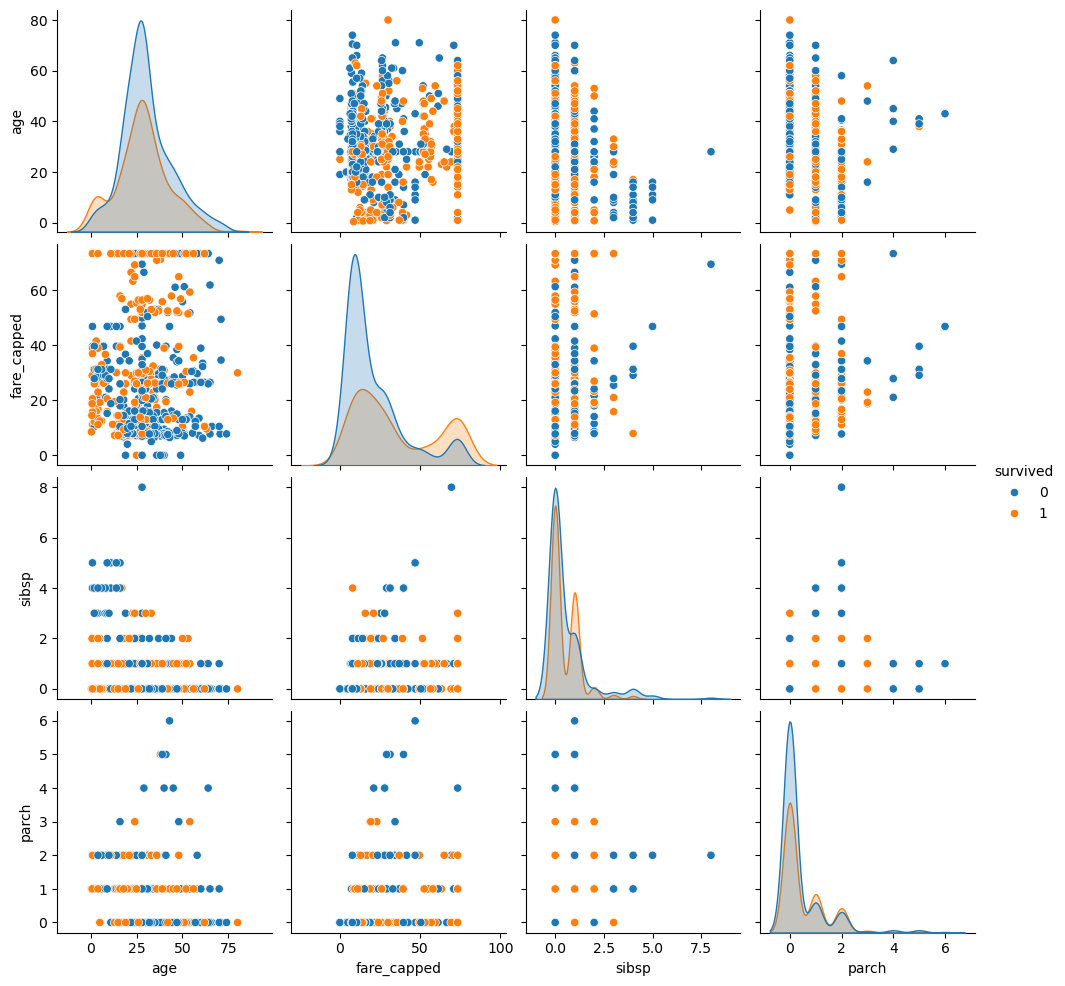

In [67]:
sns.pairplot(df_clean, vars=['age', 'fare_capped', 'sibsp', 'parch'],
hue='survived', diag_kind='kde')
plt.show()

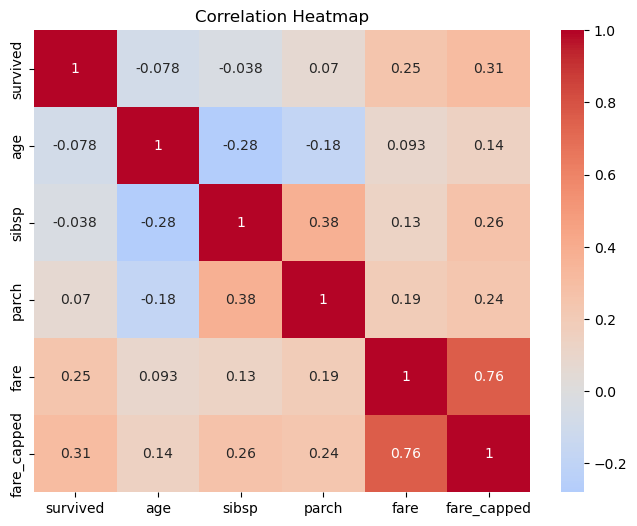

In [72]:
plt.figure(figsize=(8, 6))
numeric_cols = df_clean.select_dtypes(include=np.number).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()